In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [25]:
n = 10
I = np.identity(2*n)
L = 1 / (n ** 2) * np.block([
    [np.zeros((n,n)), np.zeros((n,n))],
    [np.ones((n,n)), np.zeros((n,n))]])
A = I - L - L.T
C = np.linalg.inv(I-L) @ L.T
S = np.diag([1/(2*n) for i in range(2*n)])
R = I - S @ np.linalg.inv(I) @ A

4.605170185988091 4.60517018598809


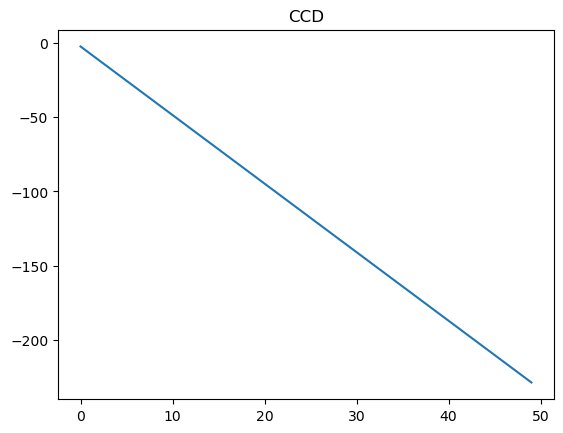

In [26]:
epochs = 50
x0 = np.ones((2 * n,1))
x = x0.copy()
x_star = np.zeros((2 * n,1))
ccd_errors = []
for l in range(epochs):
    x = C @ x
    ratio = np.linalg.norm(x - x_star) / np.linalg.norm(x0 - x_star)
    ccd_errors.append(np.log(ratio))

rho_C = np.max(np.abs(np.linalg.eigvals(C)))
ccd_rate = -np.log(rho_C)
slope, intercept = np.polyfit(range(epochs), ccd_errors, 1)
plt.plot(ccd_errors)
plt.title("CCD")
print(ccd_rate, -slope)

0.04604393850140708 0.046043938501406874


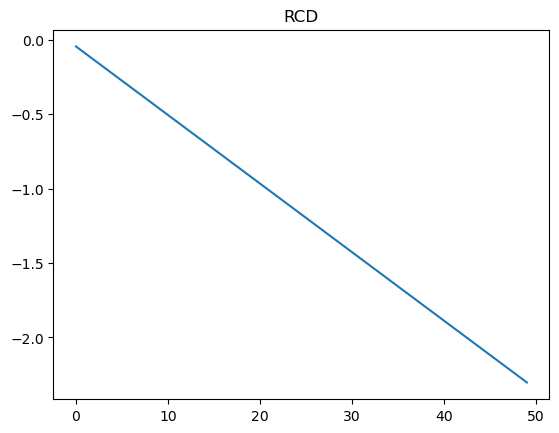

In [28]:
x0 = np.ones((2 * n,1))
x = x0.copy()
x_star = np.zeros((2 * n,1))
rcd_errors = []

for l in range(epochs):
    x = R @ x
    ratio = np.linalg.norm(x - x_star) / np.linalg.norm(x0 - x_star)
    rcd_errors.append(np.log(ratio))

rho_R = np.max(np.abs(np.linalg.eigvals(R)))
rcd_rate = -np.log(rho_R)
slope, intercept = np.polyfit(range(epochs), rcd_errors, 1)
plt.plot(rcd_errors)
plt.title("RCD")
print(rcd_rate, -slope)

In [30]:
float(ccd_rate / rcd_rate)

100.01686076110451